# 4. Model Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, 
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)
import joblib
import tensorflow as tf
plt.style.use('seaborn-v0_8-whitegrid')

## 4.1 Load Test Data and Models

In [2]:
test_df = pd.read_csv('data/TEST_scaled.csv')
print(f"TEST data: {test_df.shape}")

feature_cols = [c for c in test_df.columns if c.startswith('feat_')]
X_test = test_df[feature_cols].values
y_test = test_df['ml_target'].values
ids = test_df['id'].values

print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

TEST data: (7540, 4007)
X_test: (7540, 4005), y_test: (7540,)


In [3]:
models = {
    'kNN_k5': joblib.load('models/knn_k5.pkl'),
    'kNN_k15': joblib.load('models/knn_k15.pkl'),
    'MLP_1x64': tf.keras.models.load_model('models/mlp_1layer_64.keras'),
    'MLP_2x32': tf.keras.models.load_model('models/mlp_2layer_32.keras'),
    'MLP_1x128_drop': tf.keras.models.load_model('models/mlp_1layer_128_dropout.keras')
}

## 4.2 Generate Predictions

In [4]:
predictions = {'id': ids, 'target': y_test}

for name, model in models.items():
    print(f"Predicting with {name}...")
    if 'kNN' in name:
        pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        pred_proba = model.predict(X_test, verbose=0).flatten()
    predictions[name] = pred_proba

results_df = pd.DataFrame(predictions)
print(f"\nResults table shape: {results_df.shape}")
results_df.head(10)

Predicting with kNN_k5...
Predicting with kNN_k15...
Predicting with MLP_1x64...
Predicting with MLP_2x32...
Predicting with MLP_1x128_drop...

Results table shape: (7540, 7)


,id,target,kNN_k5,kNN_k15,MLP_1x64,MLP_2x32,MLP_1x128_drop
0,34540,0,0.385404,0.272313,0.000011,0.001102,0.000023
1,3004,1,1.000000,0.613829,0.993991,0.987741,0.999928
2,24592,0,0.000000,0.189734,0.048202,0.196097,0.034220
3,2262,0,0.000000,0.123498,0.017986,0.017598,0.039450
4,10736,0,0.000000,0.063382,0.000254,0.000241,0.000490
5,13409,1,0.443773,0.234228,0.138286,0.100518,0.260932
6,37039,0,0.413236,0.151441,0.310432,0.346888,0.276597
7,16677,0,0.203095,0.200250,0.001696,0.007080,0.000941
8,12995,0,0.000000,0.194408,0.052430,0.158990,0.018457
9,3757,1,0.563062,0.481900,0.782171,0.919398,0.691068


In [5]:
results_df.to_csv('data/results_table.csv', index=False)
print("Saved: data/results_table.csv")

Saved: data/results_table.csv


## 4.3 ROC Curves

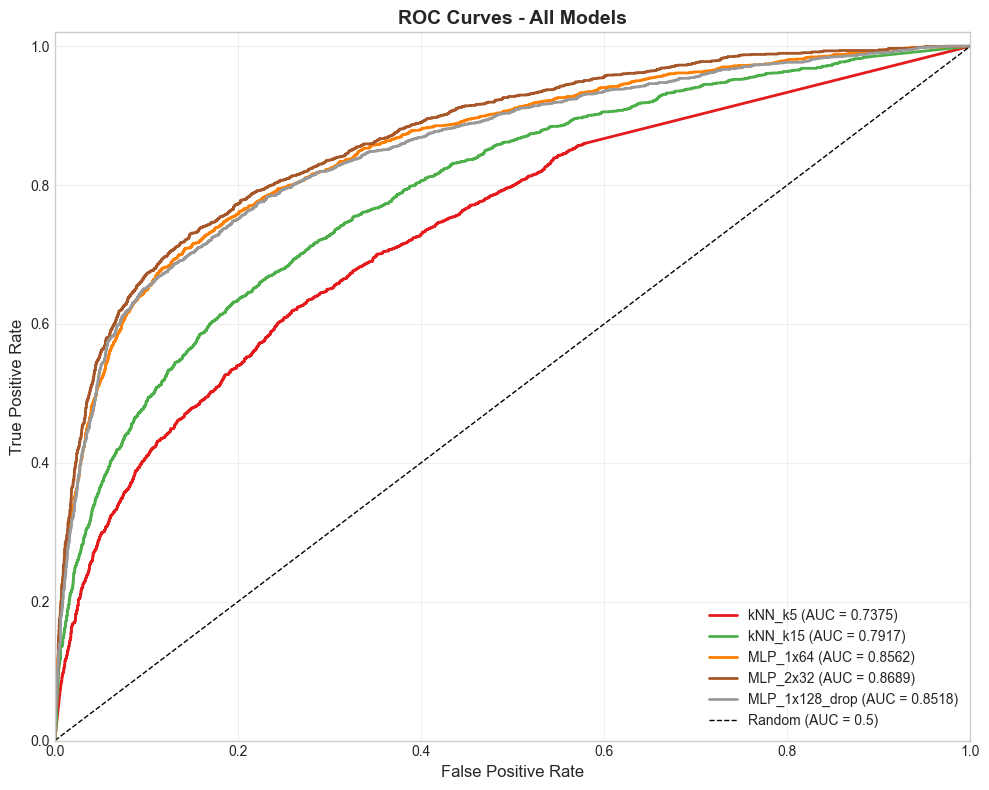

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Set1(np.linspace(0, 1, len(models)))
auc_scores = {}

for (name, _), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, results_df[name])
    auc_score = auc(fpr, tpr)
    auc_scores[name] = auc_score
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_score:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Precision-Recall Curves

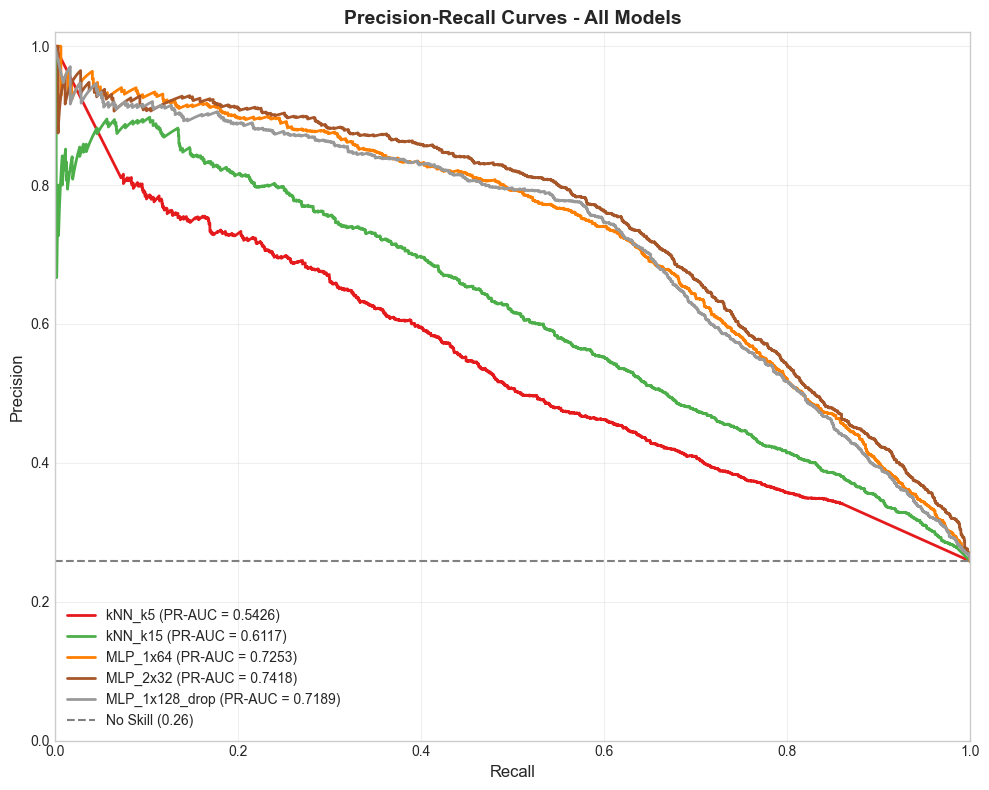

Saved: pr_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

for (name, _), color in zip(models.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, results_df[name])
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, color=color, lw=2, label=f'{name} (PR-AUC = {pr_auc:.4f})')

no_skill = y_test.mean()
ax.axhline(y=no_skill, color='gray', linestyle='--', label=f'No Skill ({no_skill:.2f})')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pr_curves.png")

## 4.5 Threshold Optimization (Youden Index)

In [8]:
def find_optimal_threshold(y_true, y_prob):
    """Find optimal threshold using Youden's J statistic"""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    return thresholds[best_idx]

optimal_thresholds = {}
for name in models.keys():
    opt_thresh = find_optimal_threshold(y_test, results_df[name])
    optimal_thresholds[name] = opt_thresh
    print(f"{name}: optimal threshold = {opt_thresh:.4f}")

kNN_k5: optimal threshold = 0.2457
kNN_k15: optimal threshold = 0.2904
MLP_1x64: optimal threshold = 0.3088
MLP_2x32: optimal threshold = 0.3242
MLP_1x128_drop: optimal threshold = 0.3176


## 4.6 Confusion Matrices & Metrics

In [9]:
metrics_list = []

for name in models.keys():
    y_pred = (results_df[name] >= optimal_thresholds[name]).astype(int)
    
    metrics_list.append({
        'Model': name,
        'AUC': auc_scores[name],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall (Sensitivity)': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Optimal Threshold': optimal_thresholds[name]
    })

metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df.sort_values('AUC', ascending=False).reset_index(drop=True)
print(metrics_df.to_string(index=False))

         Model      AUC  Accuracy  Precision  Recall (Sensitivity)  F1-Score  Optimal Threshold
      MLP_2x32 0.868890  0.820424   0.632000              0.729979  0.677465           0.324236
      MLP_1x64 0.856166  0.819098   0.634068              0.708932  0.669413           0.308792
MLP_1x128_drop 0.851838  0.822016   0.646377              0.686858  0.666003           0.317554
       kNN_k15 0.791660  0.760477   0.530630              0.631417  0.576653           0.290355
        kNN_k5 0.737453  0.709284   0.454066              0.619097  0.523892           0.245692


In [10]:
metrics_df.to_csv('data/model_metrics.csv', index=False)
print("Saved: data/model_metrics.csv")

Saved: data/model_metrics.csv


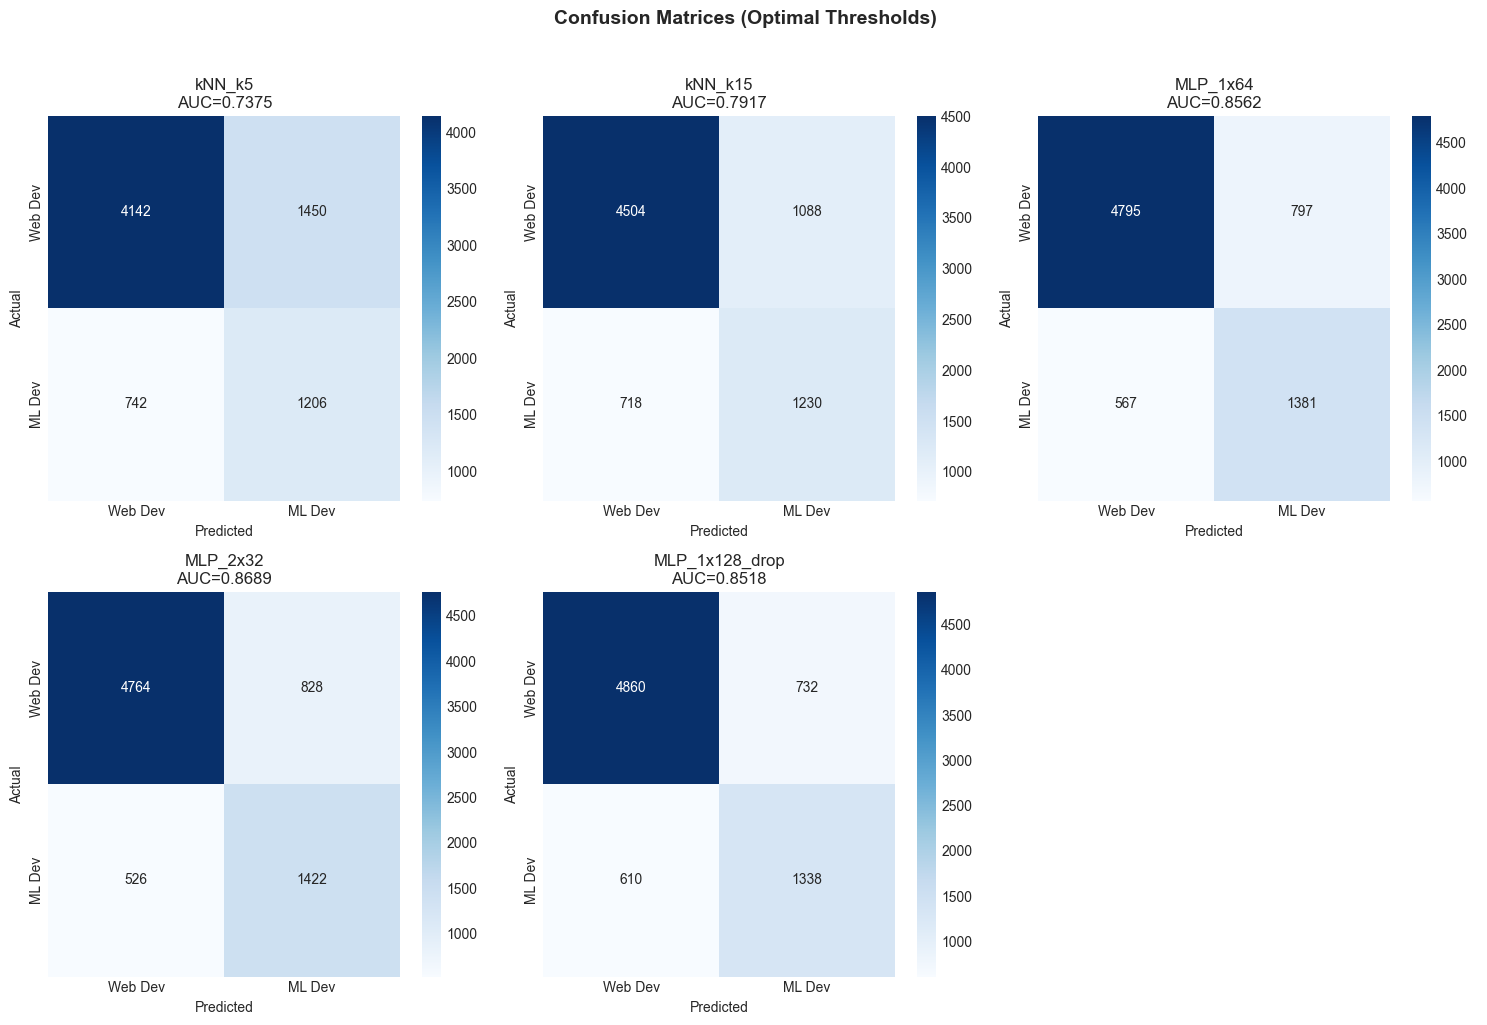

Saved: confusion_matrices.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, name in enumerate(models.keys()):
    y_pred = (results_df[name] >= optimal_thresholds[name]).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Web Dev', 'ML Dev'],
                yticklabels=['Web Dev', 'ML Dev'])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_title(f'{name}\nAUC={auc_scores[name]:.4f}')

axes[5].axis('off')

plt.suptitle('Confusion Matrices (Optimal Thresholds)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

## 4.7 Best Model Summary

In [12]:
best_model = metrics_df.iloc[0]['Model']
best_auc = metrics_df.iloc[0]['AUC']

print("SUMMARY")
print(f"""
BEST MODEL: {best_model}
Best AUC: {best_auc:.4f}
""")

SUMMARY

BEST MODEL: MLP_2x32
Best AUC: 0.8689

